In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [3]:
train_df = pd.read_csv(
    r"C:\Users\Apex-pc\Downloads\archive (2)\mitbih_train.csv.csv",
    header=None
)

test_df = pd.read_csv(
    r"C:\Users\Apex-pc\Downloads\archive (2)\mitbih_test.csv.csv",
    header=None
)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(87554, 188)
(21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
X_train = train_df.iloc[:, :-1].values
Y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
Y_test = test_df.iloc[:, -1].values

print(X_train.shape)
print(Y_train.shape)

(87554, 187)
(87554,)


In [13]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(87554, 187, 1)
(21892, 187, 1)


In [14]:
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

print(Y_train.shape)
print(Y_test.shape)

(87554, 5)
(21892, 5)


In [15]:
model = Sequential()

model.add(Conv1D(32, 3, activation='relu', input_shape=(187,1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 185, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 92, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 90, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       368,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 375,749 (1.43 MB)

 Trainable params: 375,749 (1.43 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9334 - loss: 0.2420 - val_accuracy: 0.9611 - val_loss: 0.1472
Epoch 2/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9628 - loss: 0.1394 - val_accuracy: 0.9686 - val_loss: 0.1162
Epoch 3/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9686 - loss: 0.1157 - val_accuracy: 0.9708 - val_loss: 0.1116
Epoch 4/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9717 - loss: 0.1015 - val_accuracy: 0.9751 - val_loss: 0.0926
Epoch 5/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9742 - loss: 0.0920 - val_accuracy: 0.9769 - val_loss: 0.0891
Epoch 6/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9758 - loss: 0.0853 - val_accuracy: 0.9783 - val_loss: 0.0862
Epoch 7/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9771 - loss: 0.0798 - val_accuracy: 0.9794 - val_loss: 0.0829
Epoch 8/10
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9782 - loss: 0

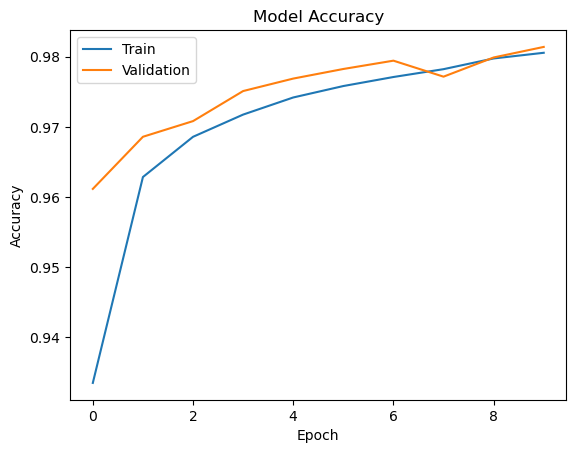

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [19]:
model.save("ecg_model.h5")

In [20]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
